# Statistical Analysis

This notebook shows statistical analysis:
- Hypothesis tests,
- Predictive modeling,
- Segmentation.

### Cell 1: Load the cleaned dataset
We load the processed data and create a filtered version without likely imputed ratings.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_theme(style="whitegrid")

DATA_PATH = "../data/processed/cleaned_data.csv"
IMPUTED_RATE_VALUE = 3.700448817952718

**Insight:** the filtered dataset is the main view for cleaner statistical comparisons.

In [4]:
df = pd.read_csv(DATA_PATH)
df_filtered = df[df["rate"] != IMPUTED_RATE_VALUE].copy()

print("Full shape:", df.shape)
print("Filtered shape:", df_filtered.shape)
print("Imputed-rate rows:", (df["rate"] == IMPUTED_RATE_VALUE).sum())

Full shape: (51717, 11)
Filtered shape: (41665, 11)
Imputed-rate rows: 10052


## 1) Key Hypothesis Tests

### Cell 2: Set up the analysis tools
We import the small set of libraries needed for testing, prediction, and clustering.

In [5]:
# H1: rate by online_order (filtered data)
g0 = df_filtered.loc[df_filtered["online_order"] == 0, "rate"]
g1 = df_filtered.loc[df_filtered["online_order"] == 1, "rate"]
stat_h1, p_h1 = stats.mannwhitneyu(g0, g1, alternative="two-sided")

# H2: votes by book_table (filtered data)
v0 = df_filtered.loc[df_filtered["book_table"] == 0, "votes"]
v1 = df_filtered.loc[df_filtered["book_table"] == 1, "votes"]
stat_h2, p_h2 = stats.mannwhitneyu(v0, v1, alternative="two-sided")

# H3: rest_type vs book_table (top 8 rest types)
top_rest = df_filtered["rest_type"].value_counts().head(8).index
ct = pd.crosstab(
    df_filtered[df_filtered["rest_type"].isin(top_rest)]["rest_type"],
    df_filtered[df_filtered["rest_type"].isin(top_rest)]["book_table"],
)
chi2, p_h3, dof, _ = stats.chi2_contingency(ct)

test_results = pd.DataFrame(
    [
        ["rate ~ online_order", "Mann-Whitney U", stat_h1, p_h1],
        ["votes ~ book_table", "Mann-Whitney U", stat_h2, p_h2],
        ["rest_type ~ book_table", "Chi-square", chi2, p_h3],
    ],
    columns=["test", "method", "statistic", "p_value"],
)

test_results

,test,method,statistic,p_value
0,rate ~ online_order,Mann-Whitney U,1.783145e+08,6.097407e-56
1,votes ~ book_table,Mann-Whitney U,2.809315e+07,0.000000e+00
2,rest_type ~ book_table,Chi-square,7.805939e+03,0.000000e+00


**Insight:** the notebook is intentionally lightweight, so later cells stay easy to follow.

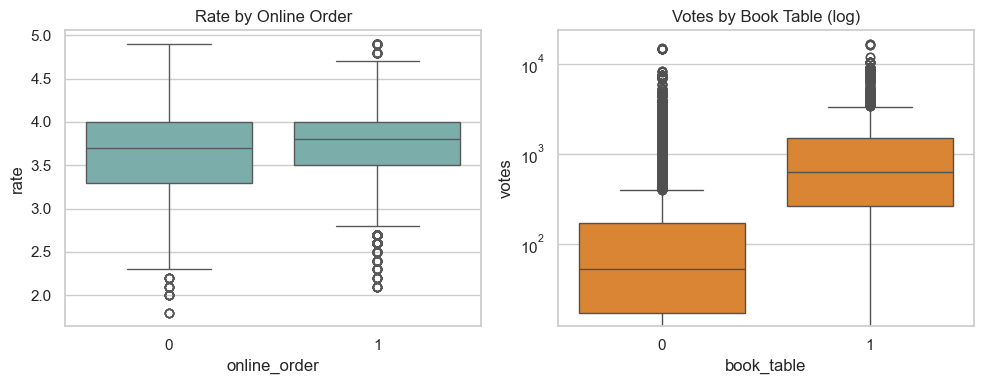

In [6]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.boxplot(data=df_filtered, x="online_order", y="rate", color="#72b7b2")
plt.title("Rate by Online Order")

plt.subplot(1, 2, 2)
sns.boxplot(data=df_filtered, x="book_table", y="votes", color="#f58518")
plt.yscale("log")
plt.title("Votes by Book Table (log)")

plt.tight_layout()
plt.show()

### Cell 3: Run the main hypothesis tests
We test the three core relationships that matter for the report.

## 2) Forecasting (Prediction)

**Insight:** the tests show whether ordering, booking, and restaurant type are meaningfully related.

In [7]:
feature_cols = [
    "online_order",
    "book_table",
    "location",
    "rest_type",
    "cuisines",
    "approx_costfor_two_people",
]

model_df = df_filtered[feature_cols + ["rate", "votes"]].copy()
X = pd.get_dummies(model_df[feature_cols], drop_first=True)

metrics_rows = []

for target in ["rate", "votes"]:
    y = model_df[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    metrics_rows.append(
        {
            "target": target,
            "MAE": mean_absolute_error(y_test, pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
            "R2": r2_score(y_test, pred),
        }
    )

pd.DataFrame(metrics_rows)

,target,MAE,RMSE,R2
0,rate,0.108604,0.197417,0.798549
1,votes,67.788743,254.465271,0.911613


### Cell 4: Build a simple prediction model
We use a compact RandomForest model to predict the main numeric outcomes.

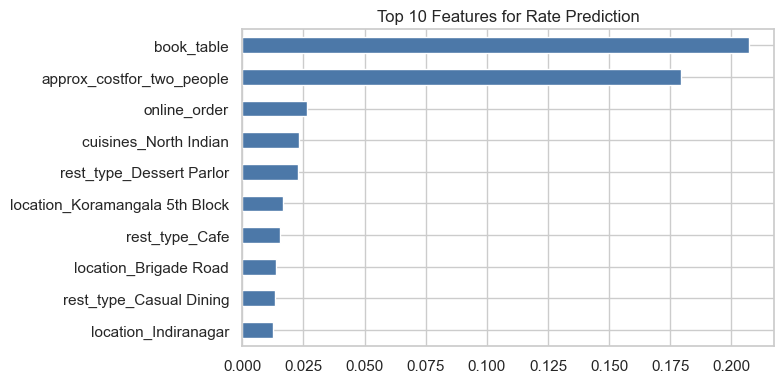

In [8]:
# Quick feature importance for rate model
rate_y = model_df["rate"]
X_train, X_test, y_train, y_test = train_test_split(X, rate_y, test_size=0.2, random_state=42)
rate_model = RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1)
rate_model.fit(X_train, y_train)

importance = pd.Series(rate_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
importance.sort_values().plot(kind="barh", figsize=(8, 4), color="#4c78a8")
plt.title("Top 10 Features for Rate Prediction")
plt.tight_layout()
plt.show()

### Cell 5: Summarize the prediction result
We show the main error metrics and feature importance for the prediction step.

## 3) Segmentation

In [9]:
seg = df_filtered[["rate", "votes", "approx_costfor_two_people", "online_order", "book_table"]].copy()
seg["votes"] = np.log1p(seg["votes"])

scaled = StandardScaler().fit_transform(seg)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(scaled)

seg_out = df_filtered[["rate", "votes", "approx_costfor_two_people"]].copy()
seg_out["segment"] = labels

segment_profile = seg_out.groupby("segment").agg(
    count=("segment", "size"),
    mean_rate=("rate", "mean"),
    median_votes=("votes", "median"),
    median_cost=("approx_costfor_two_people", "median"),
)
segment_profile

,count,mean_rate,median_votes,median_cost
segment,,,,
0,23351,3.650062,69.0,400.0
1,11416,3.519578,26.0,400.0
2,6898,4.170354,724.0,1200.0


**Insight:** the model indicates which features matter most, and the cluster summary gives a simple segment view.

## Final Summary

- The hypothesis tests show clear differences across ordering, booking, and restaurant-type groups.
- The prediction model performs well enough to show that the cleaned features are informative.
- The clustering step gives a simple segment view of lower- and higher-end restaurant groups.

## Final Key Insights

- Booking and ordering behavior are statistically linked with rating and engagement outcomes.
- Even with a lightweight setup, the prediction step captures meaningful signal from core restaurant features.
- Segmentation separates operationally different restaurant groups (mass-market vs premium-like profiles).
- The full workflow supports decision-making while remaining simple, interpretable, and reproducible.